# Introducción al Aprendizaje Automático: Taller 1
Equipo: MCMC Metropolis
* Felipe Asbún - 202010509-K - felipe.asbun@usm.cl
* Ignacio Allendes - 202004531-3 - ignacio.allendesm@usm.cl

Video: https://youtu.be/OupN4SjpW40

### Declaración ética
Declaramos que el trabajo realizado es original, con las fuentes mencionadas de referencias. Todos los miembros contribuyeron en todas las áreas, destacando los aportes de Felipe en visualización y desarrollo del Regresor Logístico, y de Ignacio en el desarrollo del Perceptron, utilización de características polinomiales y validación. Además, agradecemos la guía y las funciones entregadas por el profesor Juan Ricardo Ñanculef.

---

El objetivo de este taller consiste en familiarizarse con conceptos básicos del aprendizaje automático y con herramientas que le permitan implementar modelos competitivos correctamente.


<table align='left'>
<tr>
<td><img src='https://upload.wikimedia.org/wikipedia/commons/f/f6/Balen_Minerva_among_the_Muses_%28detail%29.jpg' width='800'/> </td>
</tr>
</table>



# Problema

La música (del griego: mousikē téchnē, "el arte de las musas") es una de las tradiciones más antiguas y universales de la cultura humana. Desde los orígenes de la especie hasta nuestros días, la música se ha desarrollado en un sin número de géneros y estilos que, gracias la tecnología, están a sólo un click de distancia.

En este notebook construiremos clasificadores para predecir el *género* de una canción usando datos obtenidos desde la conocida aplicación *Spotify*.


# Datos

Utilizaremos un dataset denominado *Spotify Tracks DB*
proveniente [*kaggle.com*](https://www.kaggle.com/), plataforma en línea para competencias de ciencia de datos y aprendizaje automático con un gran número desafíos interesantes.


In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=17tCpvpe14g2AxOgoEXi3JeHnud-YjdsS' -O T1ML_SpotifyTracksDB.csv

--2023-09-10 23:08:13--  https://docs.google.com/uc?export=download&id=17tCpvpe14g2AxOgoEXi3JeHnud-YjdsS
Resolving docs.google.com (docs.google.com)... 142.251.16.138, 142.251.16.102, 142.251.16.113, ...
Connecting to docs.google.com (docs.google.com)|142.251.16.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-00-b8-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/9ukah8i1h0edeoo99p4a7tet1bhqtifu/1694387250000/12461978637957472934/*/17tCpvpe14g2AxOgoEXi3JeHnud-YjdsS?e=download&uuid=01b02113-2a67-484a-adb2-95ada581bcea [following]
--2023-09-10 23:08:15--  https://doc-00-b8-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/9ukah8i1h0edeoo99p4a7tet1bhqtifu/1694387250000/12461978637957472934/*/17tCpvpe14g2AxOgoEXi3JeHnud-YjdsS?e=download&uuid=01b02113-2a67-484a-adb2-95ada581bcea
Resolving doc-00-b8-docs.googleusercontent.com (doc-00-b8-docs.googleusercontent.com)... 172.253.62.132, 2607:f8b0:

El dataset describe las características de 232.000 canciones y sus correspondientes géneros. Las características incluyen:


*   Bailabilidad: Medida de qué tan adecuada es una canción para bailar, según factores como la estabilidad y la fuerza del ritmo.

*   Energía: Representa la intensidad y el nivel de actividad de una canción.

*   Valencia: También conocido como "positividad", este atributo indica el estado de ánimo o la emoción de una canción, que va desde triste hasta alegre.

*   Acústica: Mide la presencia de sonidos acústicos en una pista (es decir, sonidos sin procesamiento o intervención electrónica).

*   Instrumentalidad: Determina el grado de voces en una canción.

*   Vivacidad: Indica la presencia de una audiencia en vivo en la grabación.

*   Habla: Refleja la cantidad de palabras habladas o contenido vocal en una pista.

*   Tempo: El "tempo" se refiere a la velocidad o ritmo al que se interpreta o se escucha una pieza de música. En vez de recurrir a clasificaciones tradicionales como "adagio", "andante", "allegretto grazioso", Spotify Tracks DB mide el "tempo" en pulsos por minuto (BPM).

*   Compás: Representa la estructura rítmica de la canción. Está compuesta por dos números apilados verticalmente, que generalmente aparecen al principio de una partitura. El número superior representa la cantidad de tiempos por compás. El número inferior indica el tipo de nota que representa un tiempo. Por ejemplo, la canción "Ya no te espero" de Silvio Rodriguez está compuesta en 4/4.

*   Modo: Especifica si una pista está en una tonalidad mayor (feliz) o menor (triste).

# Instrucciones

Cada una de las siguientes secciones contiene preguntas que usted deberá abordar en el video explicativo a enviar. Se evaluarán sus respuestas a cada sección (P1, P2, etc) y su nota se calculará como el promedio de todas las secciones.

Para evaluar cada parte se considerará:

*   Completitud: Se respondió o se hizo lo pedido?
*   Correctitud: Se abordó lo pedido de modo técnica o metodológicamente correcto?
*   Profundidad: Se demostró interés, espíritu crítico, espíritu de investigación, y estudio de las materias?
*   Claridad: Se explicó de modo claro y sintético lo realizado, destacando lo relevante sin caer en detalles superfluos?

Fuera de eso:

*   Originalidad: Se incluyen observaciones agudas e interesantes, o se hacen experimentos novedosos más allá de lo solicitado. Estos elementos sumarán puntos.

# Librerías

Como ya es usual utilizaremos Python y su ecosistema básico para ciencia de datos y machine learning. En particular emplearemos Scikit-learn (sklearn), una librería de alto nivel que proporciona varias herramientas para minería de datos y aprendizaje automático. Su facilidad de uso y eficiencia la convierte en una herramienta valiosa tanto por principiantes como por profesionales experimentados en el campo.
Puede modificar esto a su conveniencia.

In [ ]:
# Plotting libraries
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
# Scikit learn
import sklearn.preprocessing as skp
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
# Scikit Metrics
from sklearn.metrics import log_loss, classification_report, accuracy_score, f1_score,roc_auc_score
# Data manipulation libraries
import pandas as pd
import numpy as np
# General use
from joblib import dump, load
import warnings
warnings.filterwarnings("ignore")

sns.set(rc={'figure.figsize':(8,4)})
plt.rcParams.update({'font.size': 8})
plt.rc('xtick',labelsize=8)
plt.rc('ytick',labelsize=8)
plt.rc('axes', labelsize=8)
plt.rc('legend',fontsize=10)

## P1. Cargado de datos y Exploratorio

Como punto de partida conviene siempre explorar los datos disponibles, determinando con cuántos cuenta, de qué tipos de datos se trata, cuántas clases existen, etc.

In [ ]:
data_path = ''
file_name = 'T1ML_SpotifyTracksDB.csv'

En la siguiente celda se carga el dataset como un dataframe de la librería *pandas*, que provee muchas funcionalidades para trabajar con datos tabulares.  

In [ ]:
data_df = pd.read_csv(data_path + file_name)
display(data_df.head(5))

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0.0,0.611,0.389,99373.0,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1.0,0.246,0.590,137373.0,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3.0,0.952,0.663,170267.0,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0.0,0.703,0.240,152427.0,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4.0,0.950,0.331,82625.0,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Es fácil ver que existen varios datos faltantes, situación común en la práctica.

In [ ]:
nan_df = data_df[data_df.isna().any(axis=1)]
display(nan_df.head(5))

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
23,Movie,Jean Claude Corbel,Pourquoi aller plus loin ?,15CpJP0LXchBUjpB8RKh8m,0.0,0.669,0.707,71299.0,0.6960,0.000,C,0.197,-10.472,Major,0.0280,114.752,NaN,0.833
98,NaN,Richard M. Sherman,Forgotten Dreams,3PyfS1XmjHk1JZ004a2bFZ,0.0,NaN,0.429,89947.0,0.0478,0.959,E,0.102,-14.170,Minor,0.0468,82.388,4/4,0.111
116,Movie,Chorus,Swami Samartha Majhe Aai,3nGNIiz4PTsZ7cRhNNuSd2,0.0,0.228,0.684,203492.0,0.7460,0.000,G#,0.196,-5.847,Major,NaN,107.854,4/4,0.745
141,R&B,Nao,Make It Out Alive (feat. SiR),21Ft8ME799DMZjxNwmui6Z,64.0,0.667,0.670,239147.0,0.6490,NaN,C,0.109,-7.426,Minor,0.0875,147.935,4/4,0.618
166,R&B,Nick Jonas,"Introducing Me - From ""Camp Rock 2: The Final ...",74tQaH4CxM5Rs9BzerEbHr,68.0,0.460,NaN,186893.0,0.4960,0.000,B,0.106,-6.049,Major,0.0511,113.072,4/4,0.676


In [ ]:
print(len(nan_df)/len(data_df))

0.017845096143517026


*  Por simplicidad se eliminanemos todas las filas (registros) con datos faltantes. ¿Es esto una buena práctica? Comente.

In [ ]:
data_df = data_df.dropna()

In [ ]:
print(f'Datos presentes: {len(data_df)}')
print("Columnas del dataset:\n", data_df.columns.values)

Datos presentes: 228572
Columnas del dataset:
 ['genre' 'artist_name' 'track_name' 'track_id' 'popularity' 'acousticness'
 'danceability' 'duration_ms' 'energy' 'instrumentalness' 'key' 'liveness'
 'loudness' 'mode' 'speechiness' 'tempo' 'time_signature' 'valence']


* Determine los distintos géneros presentes en el dataset y comente. ¿Detecta alguna irregularidad en los datos? Si es así, proponga una solución.


In [ ]:
genres = data_df['genre'].unique()
print("\nGéneros:\n", genres)


Géneros:
 ['Movie' 'R&B' 'A Capella' 'Alternative' 'Country' 'Dance' 'Electronic'
 'Anime' 'Folk' 'Blues' 'Opera' 'Hip-Hop' "Children's Music"
 'Children’s Music' 'Rap' 'Indie' 'Classical' 'Pop' 'Reggae' 'Reggaeton'
 'Jazz' 'Rock' 'Ska' 'Comedy' 'Soul' 'Soundtrack' 'World']


* Gráfique la cantidad de canciones por género y comente, ¿Qué ocurrirá si creamos un modelo de clasificación en torno a esta columna?. ¿Nota alguna anomalía que pueda afectar el entrenamiento? Si es así, proponga una solución.

* R: Si entrenamos el conjunto de entrenamiento respecto a la columna del género, entonces el clasificador predecirá el género solo si le pasamos este dato, por lo que sería como una función identidad.

 Notamos que el número de canciones A Capella son despreciables respecto al resto. Para solucionar esto, podríamos crear datos A Capella ficticios que sigan la misma distribución de los originales, o bien, asignarle un peso a las clases proporcional a sus tamaños.

*Hint: Use the all powerful seaborn library for plotting*

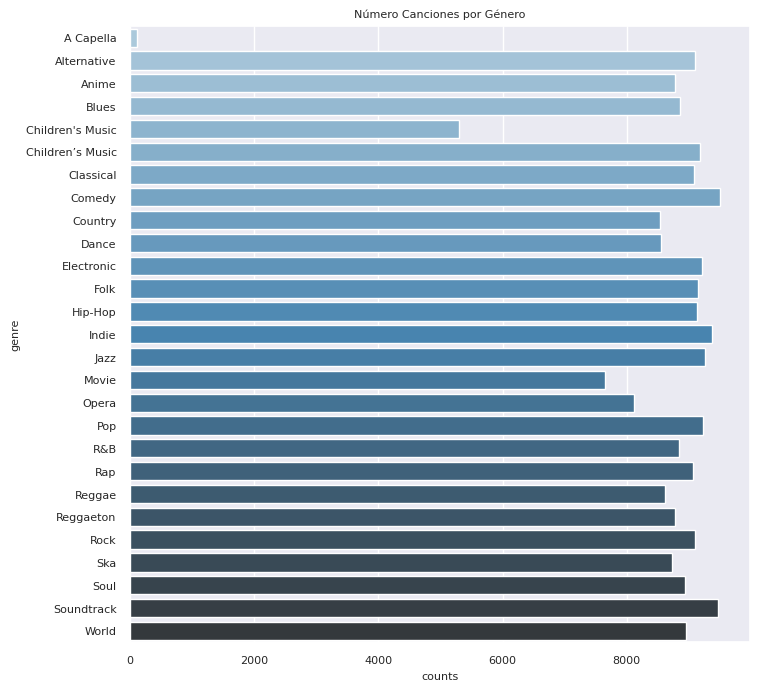

In [ ]:
gr = data_df.groupby(['genre']).size().reset_index(name='counts')
fig, ax = plt.subplots(figsize=(8,8),nrows=1)
sns.barplot(data=gr, y='genre', x='counts', palette="Blues_d", ax=ax)
ax.set_title('Número Canciones por Género',size=8)
plt.show()

* Note que hay una clase con errores de escritura. Repárela.

In [ ]:
data_df.loc[data_df['genre']=="Children’s Music", 'genre'] = "Children's Music"

* Gráfique los 30 artistas más populares y comente sobre la distibución de estos.
* R: Los 30 artistas más populares parecieran tener una distribución uniforme (aproximada).
*Hint: Use the all powerful seaborn library for plotting*

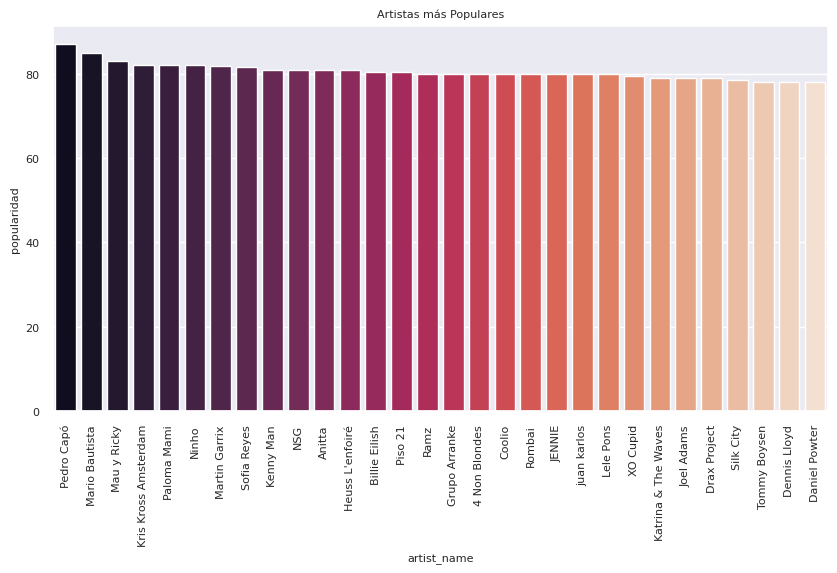

In [ ]:
gr = data_df.groupby(['artist_name'])['popularity'].mean().sort_values(ascending=False)
gr = gr.reset_index(name='popularidad').head(30)
fig, ax = plt.subplots(figsize=(10,5),nrows=1)
p = sns.barplot(data=gr, x='artist_name', y='popularidad', palette="rocket",ax=ax)
plt.setp(p.get_xticklabels(), rotation=90)
ax.set_title('Artistas más Populares',size=8)
plt.show()

## P2. Pre-procesamiento e Ingeniería de Atributos

El objetivo de esta sección es que aprenda a preparar los datos correctamente antes de aplicar un método de aprendizaje clásico y que eventualmente modifique/seleccione el conjunto de atributos que sobre los que entrenará el modelo. Por el lado más práctico, podrá familiarizarse con diferentes funcionalidades de la librería sklearn.



* Elija los 5 géneros más releventes para usted y filtre el dataset para obtener solo datos pertenecientes a los géneros de interés. Re-examine la distribución de ejemplos por clase. Repita la gráfica de 1.2 y comente *Hint: You might find Pandas "isin" method useful.*


* R: Considerando estos 5 géneros, tenemos una distribución uniforme(aproximada).

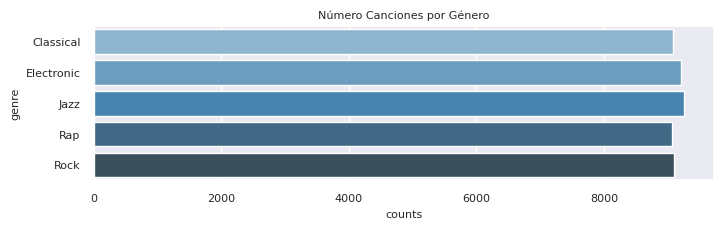

In [ ]:
genres = ['Classical','Electronic','Jazz','Rock','Rap']
data_df = data_df[data_df['genre'].isin(genres)]
genre_to_number = {label: i for i, label in enumerate(set(genres), 0)}
number_to_genre = {i: label for i, label in enumerate(set(genres), 0)}

gr = data_df.groupby(['genre']).size().reset_index(name='counts')
fig, ax = plt.subplots(figsize=(8,2),nrows=1)
sns.barplot(data=gr, y='genre', x='counts', palette="Blues_d", ax=ax)
ax.set_title('Número Canciones por Género', size=8)
plt.show()

In [ ]:
print(data_df['genre'].unique())

['Electronic' 'Rap' 'Classical' 'Jazz' 'Rock']


* Grafique las variables categóricas y continuas por género. Comente señalando qué variables considera que permiten diferenciar mejor los géneros y cuáles no. Reflexione sobre el impacto de mantener o quitar estos atributos del dataset. *Hint: Create one figure plot for continous variables and other for categorical.*

R: Los gráficos continuos en los cuales las distribuciones sean distintas son mejores, ya que nos ayudan a la existencia del hiperplano separador. Entre estos destacamos: Energy, Loudness, Danceability, Tempo e Instrumentalness.

Por otra parte, gráficos como liveness no permiten distingir una frontera de decisión buena.

* Seleccionar características permite reducir la dimensionalidad y mejorar la eficiencia del modelo a entrenar. Si le obligarán a construir un modelo que use $5 \pm 2$ características, ¿Cuáles elegiría en base a la información disponible en esta etapa?

Eligiria Energy, Loudness, Danceability, Tempo e Instrumentalness y otras dos caracteristicas más para no caer en underfitting.

['genre' 'artist_name' 'track_name' 'track_id' 'popularity' 'acousticness'
 'danceability' 'duration_ms' 'energy' 'instrumentalness' 'key' 'liveness'
 'loudness' 'mode' 'speechiness' 'tempo' 'time_signature' 'valence']


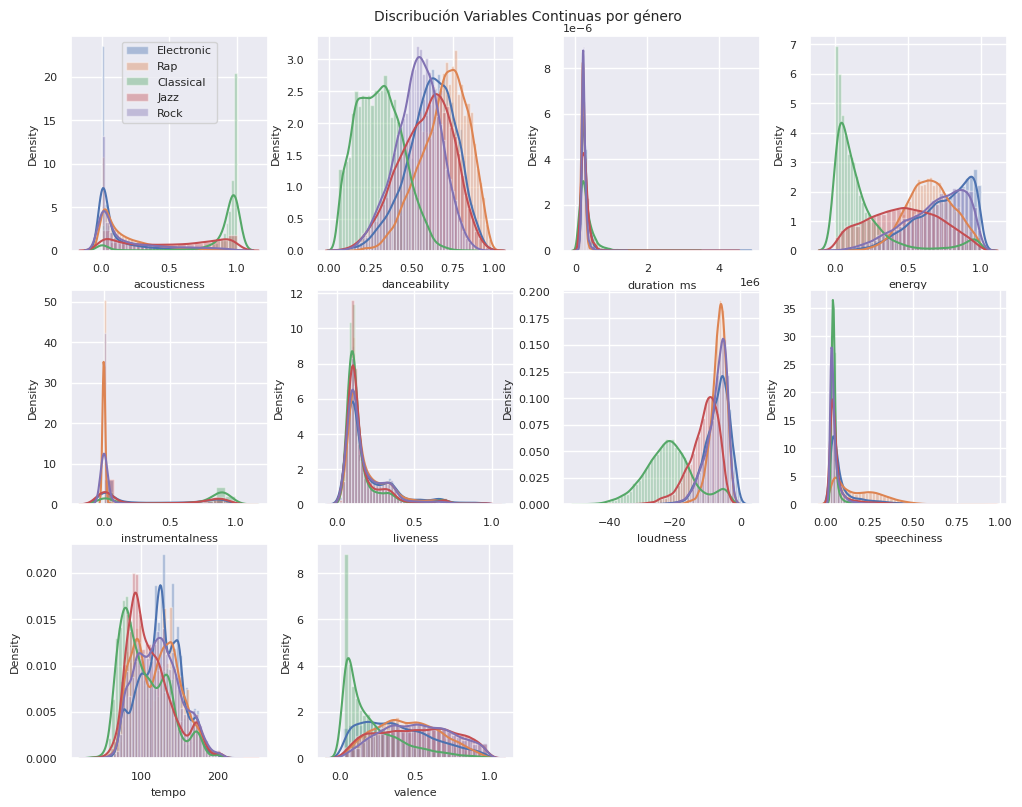

In [ ]:
print(data_df.columns.values)

# Variables continuas
cont_predictors_names = ['acousticness','danceability','duration_ms','energy',
                         'instrumentalness','liveness','loudness','speechiness',
                         'tempo','valence']
# Variables categoricas
cat_predictors = ['mode','time_signature','key']
other_predictors = ['genre','artist_name','track_name','track_id']


fig, axes = plt.subplots(figsize=(10,8), nrows=3, ncols=4)
fig.suptitle('Discribución Variables Continuas por género', fontsize=10)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
for i, column in enumerate(cont_predictors_names):
    #print(i//3, i%3)
    for genre in data_df['genre'].unique():
      target = data_df.loc[data_df['genre'] == genre]
      sns.distplot(target[column], hist=True, rug=False, kde=True,
                   ax=axes[i//4,i%4], label=genre)
      if i==0:
        axes[0,0].legend(prop={'size': 8})


axes[-1,-2].axis('off')
axes[-1,-1].axis('off')
plt.show()


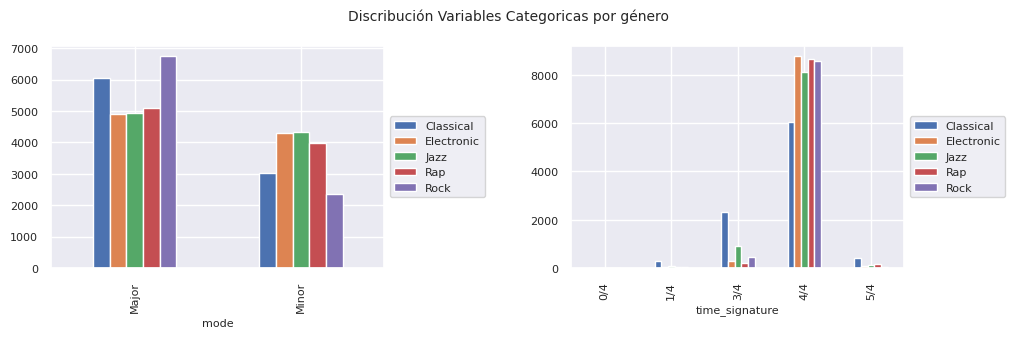

In [ ]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
fig.suptitle('Discribución Variables Categoricas por género', fontsize=10)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
for i, column in enumerate(cat_predictors[:-1]):
  df_gb = data_df.groupby([column, 'genre']).size().unstack(level=1)
  df_gb.plot(kind='bar', ax=axes[i%3])
  box = axes[i%3].get_position()
  axes[i%3].set_position([box.x0, box.y0, box.width * 0.8, box.height])
  axes[i%3].legend(loc='center left', bbox_to_anchor=(1, 0.5),prop={'size': 8})

plt.show()


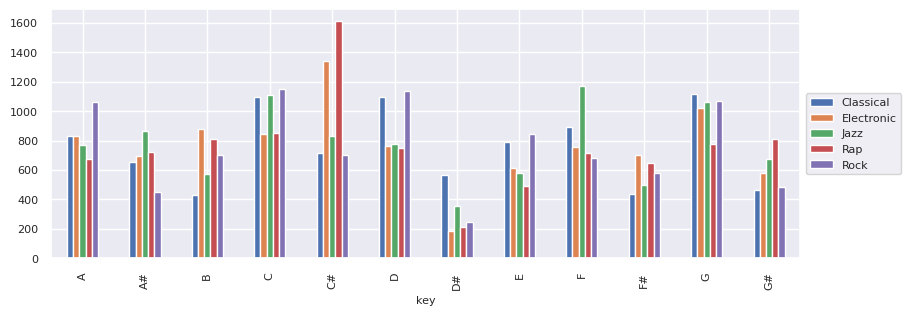

In [ ]:
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=1)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
df_gb = data_df.groupby(['key', 'genre']).size().unstack(level=1)
df_gb.plot(kind = 'bar',ax=ax)
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5),prop={'size': 8})

plt.show()

La etapa de preprocesamiento es un paso crucial en el aprendizaje automático que implica preparar y limpiar los datos para mejorar el rendimiento de los modelos. Ya hemos "tratado" *datos faltantes* y hemos considerado la posibilidad de *seleccionar características*. También explorar la presencia de valores atípicos para garantizar la calidad de los datos.






* Determine si existen atributos continuos con valores atípicos usando alguna herramienta de visualización. *Hint: Consider the use of boxplots and exploit the all power of seaborn library for plotting.*

R: Efectivamente, existen atributos con valores atípicos, como se muestra en los siguientes boxplots.

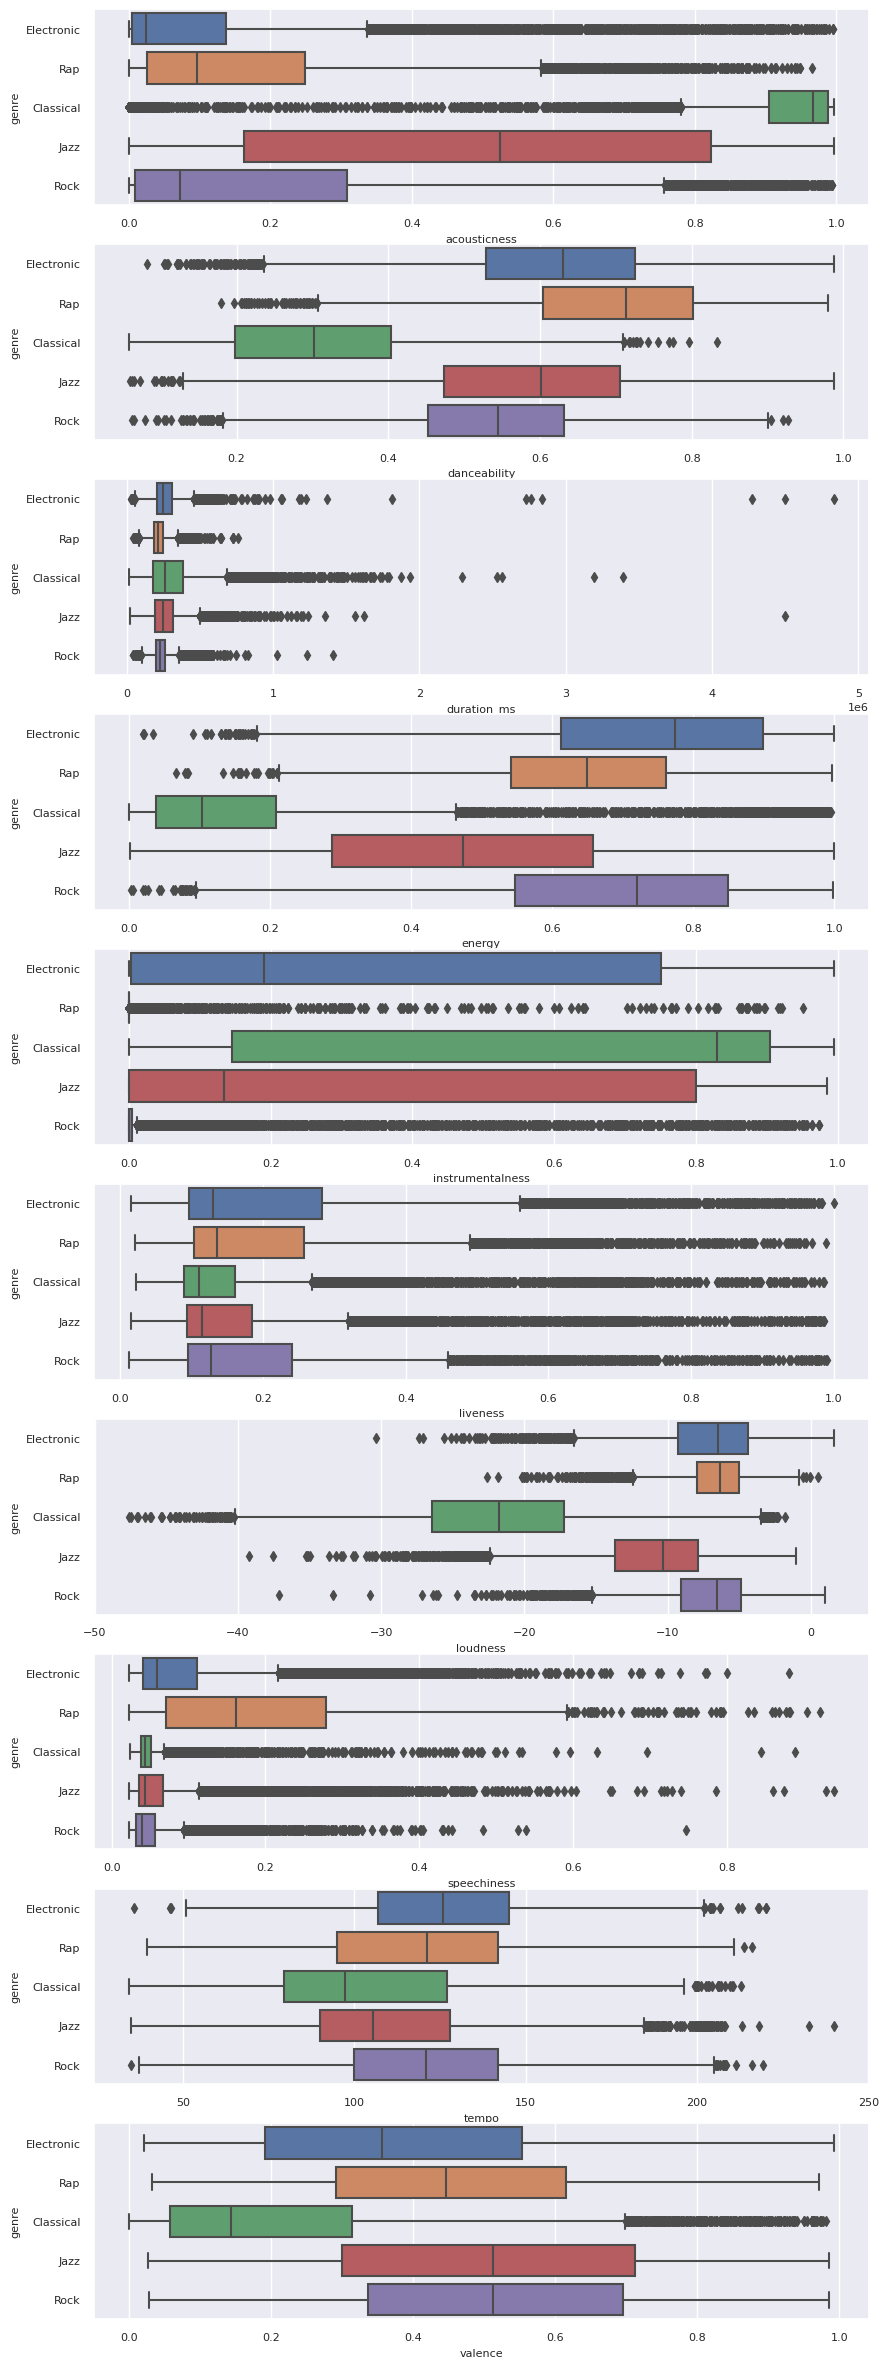

In [ ]:
cont_charact = ['acousticness','danceability','duration_ms','energy',
                         'instrumentalness','liveness','loudness','speechiness',
                         'tempo','valence']
fig, axes = plt.subplots(figsize=(10,1), nrows=10, ncols=1)
fig.tight_layout()
fig.set_figheight(30)
fig.set_figwidth(10)
for i, column in enumerate(cont_charact):
    sns.boxplot(
        data=data_df[['genre', column]],
        x=column,
        y='genre',
        ax=axes[i]
        )

Otras operaciones típicas de pre-procesamiento incluyen:



1. Escalado de Características: Estandarizar o normalizar características para asegurar que estén en escalas similares, lo que ayuda a algoritmos sensibles a diferencias de magnitud.
2. Codificación de Características Categóricas: Convertir variables categóricas en representaciones numéricas para compatibilidad con modelos.

* Para los Atributos continuos, investigue sobre el módulo *preprocessing* de scikit learn, específicamente la sección: *Preprocessing and Normalization*. A partir de lo anterior determine qué normalizador es más adecuado para cada atributo, explique el porqué de las elecciones (si sus elecciones son justificadas experimentalmente, indique claramente su metodología). Si no necesita realizar normalización sobre un atributo, explique por qué. Una vez que haya elegido sus normalizadores, aplíquelos a las columnas correspondientes.

R: Aplicamos el transformador RobustScaler de scikit learn, ya que toma en cuenta los datos atípicos en el escalado

In [ ]:
# RobustScaler para atributos continuos
cont_predictors_names = ['acousticness','danceability','duration_ms',
                         'energy','instrumentalness','liveness',
                         'loudness','speechiness','tempo','valence'
                         ]

cont_scaler = skp.RobustScaler()

* Para los atributos categóricos, al igual que los continuos, investigue sobre el módulo preprocessing de scikit learn, específicamente la sección: Preprocessing and Normalization, sin embargo, ahora fíjese en los Encoders. Determine que encoder le conviene dependiendo de los atributos categóricos y de su variable objetivo, explique el porqué de las elecciones (si sus elecciones son justificadas experimentalmente, indique claramente su metodología). Aplique los encoders determinados sobre los atributos y la columna objetivo.

R: Elegimos el encoder OneHotEncoder, ya que pasa los datos categoricos a binarios  y aprovecharemos de pasar los generos a enteros con el OrdinalEncoder.


In [ ]:
# OneHotEncoder para atributos categóricos, y OrdinalEncoder para las clases
cat_predictors = ['mode','time_signature','key']
cat_encoder = skp.OneHotEncoder(drop='if_binary')
genre_encoder = skp.OrdinalEncoder()

In [ ]:
from sklearn.compose import ColumnTransformer
# Transforma las columnas del dataframe según lo indicado anteriormente
transformer = ColumnTransformer(
    transformers=[
        ('cont', cont_scaler, cont_predictors_names),
        ('cat', cat_encoder, cat_predictors),
        ('genre', genre_encoder, ['genre'])
    ]
)

data_transformed = transformer.fit_transform(data_df)
columns_names = ['acousticness', 'danceability', 'duration_ms',
                 'energy', 'instrumentalness', 'liveness',
                 'loudness', 'speechiness', 'tempo',
                 'valence', 'mode', 'time_signature_0/4',
                 'time_signature_1/4', 'time_signature_3/4', 'time_signature_4/4',
                 'time_signature_5/4', 'key_A', 'key_A#',
                 'key_B', 'key_C', 'key_C#',
                 'key_D', 'key_D#', 'key_E',
                 'key_F', 'key_F#', 'key_G',
                 'key_G#', 'genre'
                 ]
scaled_df = pd.DataFrame(data_transformed, columns=columns_names)
display(scaled_df)

dict_genres = dict(map(lambda key, value : (key, value), data_df.genre.unique(),scaled_df.genre.unique()))
print(dict_genres)

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,...,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,genre
0,-0.057044,0.967972,-0.218164,0.438710,-0.008251,-0.458204,0.514402,3.126736,-0.434761,0.481663,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.157734,0.295374,-0.283563,0.255914,-0.008241,0.178019,0.373566,-0.210069,-0.346483,-0.591687,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.161581,-0.117438,-0.422754,0.612903,-0.008256,-0.280960,0.665690,0.229167,0.522519,-0.146699,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.233086,0.060498,-0.137595,0.230108,-0.008256,-0.510836,0.371654,-0.126736,-0.239596,-0.342298,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.259053,0.797153,2.160080,0.234409,1.270819,-0.356037,-0.166454,0.159722,0.308767,1.129584,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45720,0.628814,0.530249,-0.980968,-0.002151,-0.008256,0.394737,-0.221004,-0.194444,0.178376,1.161369,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45721,-0.214911,-0.170819,-0.183503,0.729032,-0.008226,1.617647,0.429263,2.258681,1.166028,0.520782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45722,0.630141,0.174377,-0.402794,0.376344,0.342036,1.199690,0.458833,-0.312500,-0.087498,0.520782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45723,-0.187981,0.398577,-0.244182,0.146237,-0.000814,0.657895,0.218710,1.147569,0.725028,1.114914,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0


{'Electronic': 1.0, 'Rap': 3.0, 'Classical': 0.0, 'Jazz': 2.0, 'Rock': 4.0}


De lo visto en clases podrá recordar que la representación de los datos afecta la complejidad de resolver la tarea final. En su caso, ya se dispone de varios atributos de alto nivel para hacer la predicción, pero de todos modos es posible "crear" atributos adicionales que "expandan" el espacio de características original. La celda que sigue crea atributos polinomiales a partir de los atributos continuos.



*   Prepare estos nuevos atributos apropiadamente en un dataframe separado de modo de poder evaluar su efectividad más adelante.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

cont_predictors_names = ['acousticness','danceability','duration_ms','energy','instrumentalness','liveness','loudness','speechiness','tempo','valence']
cat_predictors = ['mode','time_signature','key']

cont_features = data_df[cont_predictors_names]
cat_features = data_df[cat_predictors]

poly = PolynomialFeatures(degree=3,include_bias=False)
expanded_features = poly.fit_transform(cont_features.values)
cont_predictors_names = ['x'.join(['{}^{}'.format(pair[0],pair[1]) for pair in tuple if pair[1]!=0]) for tuple in [zip(cont_predictors_names,p) for p in poly.powers_]]
expanded_data = pd.DataFrame(expanded_features, columns = cont_predictors_names)

X = pd.concat([expanded_data.reset_index(drop=True),cat_features.reset_index(drop=True),data_df['genre'].reset_index(drop=True)],axis=1)


transformer = ColumnTransformer(
    transformers=[
        ('cont', cont_scaler, cont_predictors_names),
        ('cat', cat_encoder, cat_predictors),
        ('genre', genre_encoder, ['genre'])
    ]
)

data_transformed = transformer.fit_transform(X)
poly_df = pd.DataFrame(data_transformed, columns=cont_predictors_names+['mode', 'time_signature_0/4',
                 'time_signature_1/4', 'time_signature_3/4', 'time_signature_4/4',
                 'time_signature_5/4', 'key_A', 'key_A#',
                 'key_B', 'key_C', 'key_C#',
                 'key_D', 'key_D#', 'key_E',
                 'key_F', 'key_F#', 'key_G',
                 'key_G#', 'genre'
                 ])

In [ ]:
poly_df

,acousticness^1,danceability^1,duration_ms^1,energy^1,instrumentalness^1,liveness^1,loudness^1,speechiness^1,tempo^1,valence^1,...,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,genre
0,-0.057044,0.967972,-0.218164,0.438710,-0.008251,-0.458204,0.514402,3.126736,-0.434761,0.481663,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.157734,0.295374,-0.283563,0.255914,-0.008241,0.178019,0.373566,-0.210069,-0.346483,-0.591687,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.161581,-0.117438,-0.422754,0.612903,-0.008256,-0.280960,0.665690,0.229167,0.522519,-0.146699,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.233086,0.060498,-0.137595,0.230108,-0.008256,-0.510836,0.371654,-0.126736,-0.239596,-0.342298,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.259053,0.797153,2.160080,0.234409,1.270819,-0.356037,-0.166454,0.159722,0.308767,1.129584,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45720,0.628814,0.530249,-0.980968,-0.002151,-0.008256,0.394737,-0.221004,-0.194444,0.178376,1.161369,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45721,-0.214911,-0.170819,-0.183503,0.729032,-0.008226,1.617647,0.429263,2.258681,1.166028,0.520782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45722,0.630141,0.174377,-0.402794,0.376344,0.342036,1.199690,0.458833,-0.312500,-0.087498,0.520782,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
45723,-0.187981,0.398577,-0.244182,0.146237,-0.000814,0.657895,0.218710,1.147569,0.725028,1.114914,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0


## P3. Conjunto de Entrenamiento, Validación y Pruebas


El objetivo de esta sección es que aprenda a generar sus propios conjuntos de entrenamiento, validación y Prueba. Comprendiendo correctamente el uso de cada uno en las distintas etapas de generación de modelos de aprendizaje automático.

* Divida su conjunto de datos en entrenamiento, prueba y validación. Tome en cuenta la necesidad de *reproducibilidad* al momento de hacer los splits (muy común en ciencia). Justifique adecuadamente el tamaño de cada conjunto. *Hint: You might find "train_test_split" pretty useful here*.

R: Decidimos dividir el conjunto en 16/30 de entrenamiento, 4/30 de validación y 1/3 de test ya que encontramos que es equilibrado. Especificando el random_state podemos asegurarnos de la reproducibilidad.

In [ ]:
from sklearn.model_selection import train_test_split

X = scaled_df.drop('genre', axis=1)
Y = pd.DataFrame(data=scaled_df.genre)

X_Train, X_test, y_Train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_Train, y_Train, test_size=0.2, random_state=52)

display(X_train)
display(y_train)


#Datos Polinomiales
X_poly= poly_df.drop('genre',axis=1)
y_poly=poly_df['genre']
X_Train_poly, X_test_poly, y_Train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.33, random_state=42)

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,...,key_B,key_C,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#
38382,0.870257,-0.252669,-0.392545,-0.821505,-0.002340,-0.287152,-1.290084,0.006944,-0.790018,0.176039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
27126,0.863624,-0.604982,-0.580818,-0.490323,-0.008256,-0.085139,-0.486362,0.069444,0.625918,-0.080685,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34198,-0.258583,-0.850534,-0.117495,0.735484,-0.008256,-0.219814,0.583992,0.743056,0.695284,-0.391198,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34328,-0.180287,-0.355872,-0.320289,0.443011,-0.003459,2.105263,-0.127326,1.060764,0.925002,0.481663,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
26039,1.018838,-0.081851,-0.375918,-0.929032,1.241749,0.348297,-1.304614,0.881944,0.544074,-0.381418,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42888,-0.259667,-0.416370,0.025220,0.681720,-0.008077,-0.273994,0.487892,0.267361,0.369186,-0.220049,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42390,0.038472,0.384342,1.561896,0.554839,-0.008198,-0.476006,-0.333163,-0.067708,-0.526982,1.310513,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12295,0.206951,0.740214,-0.369261,-0.032258,-0.008256,0.023220,0.197425,4.151042,-0.606616,0.865526,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32278,0.183072,-0.473310,1.025419,-0.305376,-0.007031,-0.265480,0.068825,-0.402778,-0.215485,0.017115,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


,genre
38382,2.0
27126,0.0
34198,4.0
34328,4.0
26039,0.0
...,...
42888,4.0
42390,4.0
12295,3.0
32278,4.0


* Explique cuál es el rol del conjunto de entrenamiento en la creación de modelos de aprendizaje automático.


R: Ajustar los parámetros de nuestro modelo. En el caso del Perceptron, ajustamos los valores w, b en un intento de separar las clases.

* Señale cuál es el rol del conjunto de pruebas en la creación de modelos de aprendizaje automático.


R: Con el conjunto de pruebas podemos verificar si ocurre *overfitting* y estudiar la capacidad de generalización del modelo.

* Indique la función que cumple el conjunto de validación en la creación de modelos de aprendizaje automático.

R: Se utiliza para ajustar los hiperparametros del modelo, sin que este mismo aprenda directamente de estos datos

## P4. El Perceptrón

El objetivo de esta sección consiste en aprender a entrenar un perceptrón y evaluarlo usando métricas y métodos apropiados.


* Entrene un perceptrón para clasificar los géneros de las canciones. Como el perceptrón es nativamente binario, concéntrese primero en 2 géneros. Para comenzar, implemente el método "from scratch" sin los "add-ons" que suele tener en implementaciones "modernas". Determine si observa convergencia y comente. ¿Depende lo anterior de la elección de la *tasa de aprendizaje*? ¿Observa diferencias entre los métodos denominados "train_online" y "train"?

R: Con epoch=5, y eta=0.2 observamos convergencia hacia un missratio de 0.182. Sin embargo, cambiando a eta=1 observamos la misma convergencia, lo cual no debiese de ocurrir. También, notamos que las funciones train_online y train se corresponden al algoritmo visto en clases, con la diferencia de que train va actualizando el factor etat con eta, mientras que train_online no. Por esto, train_online se demora mucho mas.

In [ ]:
"""
WARNING: Los métodos para entrenar el modelo (train y train_online) asumen que X es una matriz de nxd.
El número de filas (n) es el número de ejemplos y el número de columnas (d) es el número total de características.
Por otro lado Y se asume una matriz de nx1 que identifica la clase a la que pertenece c/dato.
Los datos de la clase positiva están codificados como +1 y los datos de la otra clase como -1.
"""

def predict(x,w,b):
  log_odd = b
  for i in range(len(w)):
    log_odd += w[i] * x[i]
  return 1.0 if log_odd >= 0.0 else -1.0

def eval(X,Y,w,b):
  mistakes = 0.0
  for idx in range(len(X)):
    prediction = predict(X[idx,:], w, b)
    if Y[idx]*prediction < 0:
      mistakes += 1.0
  miss_rate = mistakes/float(len(X))
  return miss_rate

def train_online(X,Y,eta=1,n_epochs=5,tolerance=0):
  w = [0.0 for i in range(X.shape[1])]; b = 0.0;
  history = []
  for epoch in range(n_epochs):
    mistakes = 0.0
    for idx in range(len(X)):
      prediction = predict(X[idx,:], w, b)
      if Y[idx]*prediction < 0:
        w = w + eta*Y[idx]*X[idx,:]
        b = b + eta*Y[idx]
        mistakes += 1.0
      if idx%10 == 0:
        miss_rate_history = eval(X,Y,w,b)
        history.append(miss_rate_history)
        #print('.... %d examples, miss_rate=%.3f'%(idx+1, miss_rate_history))
    miss_rate = mistakes/len(X)
    print('> epoch=%d, miss_rate=%.3f' % (epoch+1, miss_rate))
    if miss_rate < tolerance:
      return w,b,history
  return w,b,history

def train(X,Y,eta=1,n_epochs=5,tolerance=0):
  w = [0.0 for i in range(X.shape[1])]; b = 0.0;
  history = []
  etat = eta
  for epoch in range(n_epochs):
    mistakes = 0.0
    delta_w=np.zeros_like(w); delta_b=0;
    for idx in range(len(X)):
      prediction = predict(X[idx,:], w, b)
      if Y[idx]*prediction < 0:
        delta_w+=etat*Y[idx]*X[idx,:]
        delta_b+=etat*Y[idx]
        mistakes += 1.0
      if idx%100 == 0:
        w = w + delta_w/100
        b = b + delta_b/100
        delta_w=0; delta_b=0;
        etat = eta/(1+(epoch*idx/100))
        miss_rate_history = eval(X,Y,w,b)
        history.append(miss_rate_history)
    miss_rate = mistakes/len(X)
    print('> epoch=%d, miss_rate=%.3f' % (epoch+1, miss_rate))
    if miss_rate < tolerance:
      return w,b,history
  return w,b,history

In [ ]:
X_elec_rap = scaled_df.loc[scaled_df['genre'].isin([1,3])]
X_elec_rap['genre'] = X_elec_rap['genre']-2

X_er_train, X_er_test, y_er_train, y_er_test = train_test_split(X_elec_rap.drop(columns='genre'), X_elec_rap.genre, test_size=0.33)

In [ ]:
# Entrenando el Perceptrón

w, b, historial = train(X_er_train.values, y_er_train.values, eta=0.2, tolerance=0.1)

> epoch=1, miss_rate=0.279
> epoch=2, miss_rate=0.181
> epoch=3, miss_rate=0.178
> epoch=4, miss_rate=0.179
> epoch=5, miss_rate=0.180


In [ ]:
w, b, historial = train(X_er_train.values, y_er_train.values, eta=10, tolerance=0.1)

> epoch=1, miss_rate=0.279
> epoch=2, miss_rate=0.181
> epoch=3, miss_rate=0.178
> epoch=4, miss_rate=0.179
> epoch=5, miss_rate=0.180


In [ ]:
w_online, b_online, historial_online = train_online(X_er_train.values, y_er_train.values, eta=0.2, tolerance=0.1)

> epoch=1, miss_rate=0.248
> epoch=2, miss_rate=0.243
> epoch=3, miss_rate=0.240
> epoch=4, miss_rate=0.240
> epoch=5, miss_rate=0.240


* Compare la exactitud obtenida (accuracy) con la exactitud de un clasificador que elige aleatoriamente la clase a predecir. Verifique experimentalmente su respuesta.

R: La exactitud del Perceptron con train es del 83%, con train_online es del 80%, mientras que elegir al azar es del 50% aprox, como se puede observar experimentalmente:

In [ ]:
print('Train accuracy \n')
print(eval(X_er_test.values, y_er_test.values, w, b))

print('\nTrain Online accuracy \n')
print(eval(X_er_test.values, y_er_test.values, w_online, b_online))

print('\nRandom accuracy \n')
print(eval(X_er_test.values, np.random.choice([1,-1],(len(y_er_test.values),1)), w_online, b_online))

Train accuracy 

0.18299353555445053

Train Online accuracy 

0.21929388363998012

Random accuracy 

0.5002486325211337


* Visualice el peso que el modelo asigna a las diferentes características y comente.

R: Podemos observar que el Perceptron de train y train_online basan su decisión principalmente en el instrumentalness de la canción.

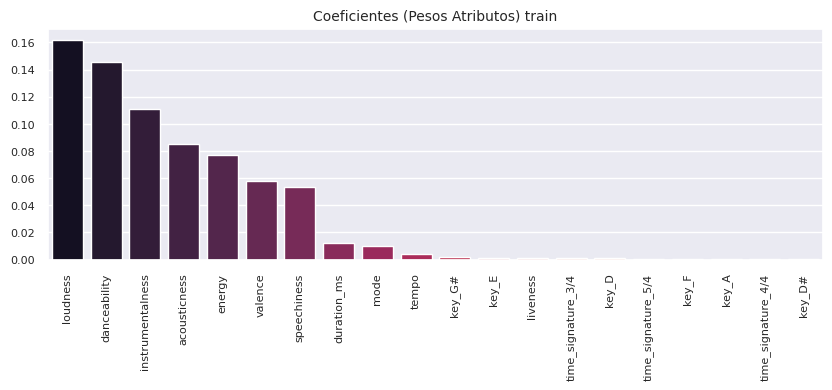

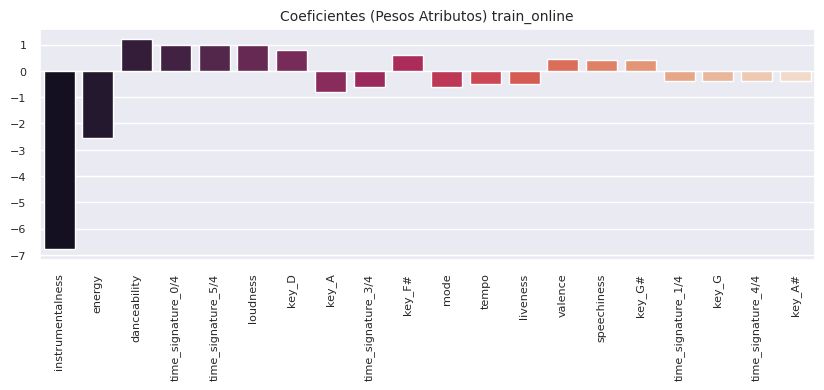

In [ ]:
max_feat = min(len(w),20)
sorted_idx = np.argsort(np.abs(w))[::-1]

fig, ax = plt.subplots(figsize=(10,3),nrows=1)
p = sns.barplot(x=np.arange(max_feat), y=[w[idx] for idx in sorted_idx[:max_feat]], palette="rocket",ax=ax)
ax.set_xticklabels([columns_names[idx] for idx in sorted_idx[:max_feat]])
plt.setp(p.get_xticklabels(), rotation=90)
ax.set_title('Coeficientes (Pesos Atributos) train',size=10)
plt.show()

max_feat = min(len(w_online),20)
sorted_idx = np.argsort(np.abs(w_online))[::-1]
fig, ax = plt.subplots(figsize=(10,3),nrows=1)
p = sns.barplot(x=np.arange(max_feat), y=[w_online[idx] for idx in sorted_idx[:max_feat]], palette="rocket",ax=ax)
ax.set_xticklabels([columns_names[idx] for idx in sorted_idx[:max_feat]])
plt.setp(p.get_xticklabels(), rotation=90)
ax.set_title('Coeficientes (Pesos Atributos) train_online',size=10)
plt.show()

* Mencione tres métricas relevantes para un problema de clasificación multiclase que vayan más allá de "exactitud" (accuracy). Comente detalladamente sus diferencias y relevancias. Desde acá en adelante puede emplear el método Perceptron disponible en sklearn.


R: Consideremos las siguientes tres metricas:

* _precision_:
Es el cuociente
$$
Precision = \frac{TP}{TP + FP}
$$
correspondiente a la proporción de identificadores positivos correctos.

* _recall_:
Es el cuociente
$$
Recall = \frac{TP}{TP + FN}
$$
correspondiente a la proporción de positivos reales que se identificaron de forma correcta.

* _f1-score_: Corresponde a la media armónica entre precision y recall

In [ ]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report

n_classes = 5
base = Perceptron(tol=1e-3,eta0=0.1,random_state=123)
clf = base.fit(X_train.values, y_train.values)
target_names = [number_to_genre[i] for i in clf.classes_]
print(classification_report(y_train.values, clf.predict(X_train.values), target_names=target_names))

              precision    recall  f1-score   support

   Classical       0.86      0.65      0.74      4926
         Rap       0.42      0.72      0.53      4904
        Jazz       0.52      0.38      0.44      4989
        Rock       0.75      0.34      0.47      4864
  Electronic       0.52      0.70      0.60      4825

    accuracy                           0.56     24508
   macro avg       0.61      0.56      0.56     24508
weighted avg       0.61      0.56      0.56     24508




* Para manejar múltiples clases, utilice primero el método **"One versus the Rest"** y luego el método **"OneVsOne"**. Compárelos adecuadamente usando las 3 métricas definidas anteriormente. Mida también el tiempo de entrenamiento.

In [ ]:
import time

start = time.time()
clf_ovo_perceptron = OneVsOneClassifier(base).fit(X_train.values, y_train.values)
end = time.time()
print("Tiempo de ejecución de OVO:",end-start)
print("Reporte de OVO:")
print(classification_report(y_train.values, clf_ovo_perceptron.predict(X_train.values), target_names=target_names))

start = time.time()
clf_ovr_perceptron = OneVsRestClassifier(base).fit(X_train.values, y_train.values)
end = time.time()
print("Tiempo de ejecución de OVR:",end-start)
print("Reporte de OVR:")
print(classification_report(y_train.values, clf_ovr_perceptron.predict(X_train.values), target_names=target_names))

Tiempo de ejecución de OVO: 0.24497032165527344
Reporte de OVO:
              precision    recall  f1-score   support

   Classical       0.86      0.59      0.70      4926
         Rap       0.39      0.52      0.45      4904
        Jazz       0.44      0.69      0.54      4989
        Rock       0.69      0.22      0.33      4864
  Electronic       0.62      0.68      0.64      4825

    accuracy                           0.54     24508
   macro avg       0.60      0.54      0.53     24508
weighted avg       0.60      0.54      0.53     24508

Tiempo de ejecución de OVR: 0.3321115970611572
Reporte de OVR:
              precision    recall  f1-score   support

   Classical       0.75      0.81      0.78      4926
         Rap       0.71      0.24      0.36      4904
        Jazz       0.48      0.36      0.41      4989
        Rock       0.62      0.71      0.66      4864
  Electronic       0.46      0.77      0.57      4825

    accuracy                           0.58     24508
   m

In [ ]:
#balanced
start = time.time()
base = Perceptron(tol=1e-3, eta0=0.1, random_state=123, class_weight='balanced')
clf_ovr_balanced_perceptron = OneVsRestClassifier(base).fit(X_train.values, y_train.values)
end = time.time()
print("Tiempo de ejecución de OVR:",end-start)
print("Reporte de OVR:")
print(classification_report(y_train.values, clf_ovr_balanced_perceptron.predict(X_train.values), target_names=target_names))

Tiempo de ejecución de OVR: 0.24614906311035156
Reporte de OVR:
              precision    recall  f1-score   support

   Classical       0.62      0.87      0.72      4926
         Rap       0.51      0.39      0.45      4904
        Jazz       0.71      0.15      0.24      4989
        Rock       0.61      0.72      0.66      4864
  Electronic       0.48      0.70      0.57      4825

    accuracy                           0.56     24508
   macro avg       0.59      0.57      0.53     24508
weighted avg       0.59      0.56      0.53     24508




* ¿Qué técnica (OVO vs OVR) muestra mejor desempeño en entrenamiento?

R: OVR

* ¿Qué técnica (OVO vs OVR) muestra mejor capacidad de generalización?

R: OVR

* Elija uno de los modelos y estime su error de predicción si se decidiera operar con él en la tarea.

Nuestra estimación del error de predicción será el cuociente entre casos favorables y casos totales. Por ende, tenemos un error de predicción ~0.578

In [ ]:
print("Score Perceptron OVO on Training Set:    %.3f" % clf_ovo_perceptron.score(X_train, y_train))
print("Score Perceptron OVO on Validation Set:  %.3f" % clf_ovo_perceptron.score(X_val, y_val))
print("Score Perceptron OVO on Test Set:        %.3f" % clf_ovo_perceptron.score(X_test, y_test))

print("\nScore Perceptron OVR on Training Set:    %.3f" % clf_ovr_perceptron.score(X_train, y_train))
print("Score Perceptron OVR on Validation Set:  %.3f" % clf_ovr_perceptron.score(X_val, y_val))
print("Score Perceptron OVR on Test Set:        %.3f" % clf_ovr_perceptron.score(X_test, y_test))

comparacion=clf_ovr_perceptron.predict(X_test)==np.array(y_test).T
accuracy = np.sum(comparacion.astype(int))/comparacion.shape[1]
print("\nAccuracy Perceptron OVR on Test Set:     %.3f" % accuracy)

Score Perceptron OVO on Training Set:    0.539
Score Perceptron OVO on Validation Set:  0.535
Score Perceptron OVO on Test Set:        0.547

Score Perceptron OVR on Training Set:    0.579
Score Perceptron OVR on Validation Set:  0.577
Score Perceptron OVR on Test Set:        0.578

Accuracy Perceptron OVR on Test Set:     0.578


### Guardar

El código de más abajo guarda un modelo. Si usted entrenó un modelo con buen desempeño puede valer la pena ejecutar este paso.

In [ ]:
# dump(model, 'filename.joblib')

## P5.  El Regresor Logístico

* Entrene un regresor logístico para clasificación. Este método puede trabajar directamente con múltiples clases, pero de todos modos es posible entrenarlo usando **"One versus the Rest"** y **"OneVsOne"**. Compare las 3 metodologías usando las 3 métricas definidas en la sección anterior. Mida también el tiempo de entrenamiento.


In [ ]:
import time

base = LogisticRegression()
start = time.time()
clf_log = LogisticRegression().fit(X_train, y_train)
end = time.time()
print("Tiempo de ejecución de LogisticRegression:",end-start)
print("Reporte de LogisticRegression:")
print(classification_report(y_test, clf_log.predict(X_test), target_names=target_names))

start = time.time()
clf_ovo_log = OneVsOneClassifier(base).fit(X_train, y_train)
end = time.time()
print("Tiempo de ejecución de LogisticRegression OVO: ",end-start)
print("Reporte de LogisticRegression OVO:")
print(classification_report(y_test, clf_ovo_log.predict(X_test), target_names=target_names))

start = time.time()
clf_ovr_log = OneVsRestClassifier(base).fit(X_train, y_train)
end = time.time()
print("Tiempo de ejecución de LogisticRegression OVR:",end-start)
print("Reporte de LogisticRegression OVR:")
print(classification_report(y_test, clf_ovr_log.predict(X_test), target_names=target_names))

Tiempo de ejecución de LogisticRegression: 1.1277759075164795
Reporte de LogisticRegression:
              precision    recall  f1-score   support

   Classical       0.83      0.85      0.84      2943
         Rap       0.65      0.52      0.58      3133
        Jazz       0.63      0.54      0.58      3020
        Rock       0.68      0.78      0.73      2956
  Electronic       0.62      0.73      0.67      3038

    accuracy                           0.68     15090
   macro avg       0.68      0.69      0.68     15090
weighted avg       0.68      0.68      0.68     15090

Tiempo de ejecución de LogisticRegression OVO:  1.0481109619140625
Reporte de LogisticRegression OVO:
              precision    recall  f1-score   support

   Classical       0.84      0.86      0.85      2943
         Rap       0.67      0.55      0.60      3133
        Jazz       0.63      0.57      0.60      3020
        Rock       0.71      0.77      0.74      2956
  Electronic       0.63      0.73      0.68  

* Visualice la matriz de confusión correspondiente al modelo entrenado. Comente cuáles son las clases que más se confunden.

{'Electronic': 1.0, 'Rap': 3.0, 'Classical': 0.0, 'Jazz': 2.0, 'Rock': 4.0}


Text(0.5, 1.0, 'OVR')

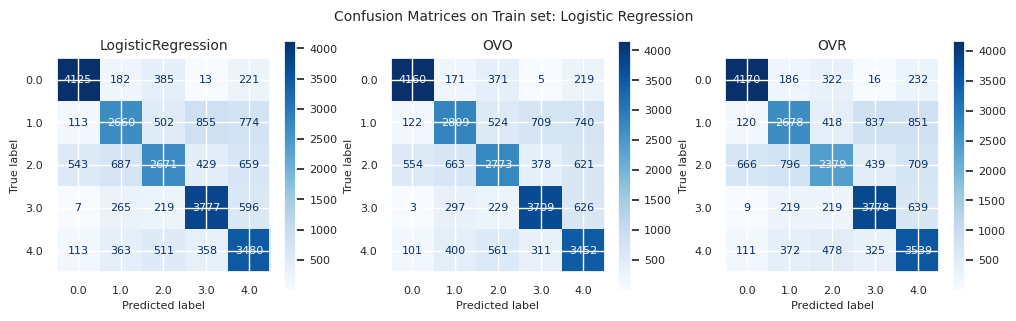

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print(dict_genres)

fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=3)
fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.suptitle('Confusion Matrices on Train set: Logistic Regression', fontsize=10, y=1.05)

cm = confusion_matrix(y_train, clf_log.predict(X_train), labels=clf_log.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf_log.classes_)
disp.plot(cmap = "Blues", ax=axes[0])
axes[0].set_title('LogisticRegression', fontsize=10)

cm = confusion_matrix(y_train, clf_ovo_log.predict(X_train), labels=clf_ovo_log.classes_)
dispovo = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf_ovo_log.classes_)
dispovo.plot(cmap = "Blues", ax=axes[1])
axes[1].set_title('OVO', fontsize=10)


cm = confusion_matrix(y_train, clf_ovr_log.predict(X_train), labels=clf_ovr_log.classes_)
dispovr = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf_ovr_log.classes_)
dispovr.plot(cmap = "Blues", ax=axes[2])
axes[2].set_title('OVR', fontsize=10)


* ¿Anticipa el error de entrenamiento el error de predicción observado? ¿Anticipa el desempeño sobre el conjunto de validación el error de predicción observado?

* Sí, puesto que los scores de entrenamiento y validación son similares al de predicción.

In [ ]:
print("Score LogisticRegression on Training Set: %.3f" % clf_log.score(X_train, y_train))
print("Score LogisticRegression on Validation Set: %.3f" % clf_log.score(X_val, y_val))
print("Score LogisticRegression on Test Set: %.3f" % clf_log.score(X_test, y_test))

print("\nScore LogisticRegression OVO on Training Set: %.3f" % clf_ovo_log.score(X_train, y_train))
print("Score LogisticRegression OVO on Validation Set: %.3f" % clf_ovo_log.score(X_val, y_val))
print("Score LogisticRegression OVR on Test Set: %.3f" % clf_ovo_log.score(X_test, y_test))

print("\nScore LogisticRegression OVR on Training Set: %.3f" % clf_ovr_log.score(X_train, y_train))
print("Score LogisticRegression OVR on Validation Set: %.3f" % clf_ovr_log.score(X_val, y_val))
print("Score LogisticRegression OVR on Test Set: %.3f" % clf_ovr_log.score(X_test, y_test))

Score LogisticRegression on Training Set: 0.682
Score LogisticRegression on Validation Set: 0.671
Score LogisticRegression on Test Set: 0.684

Score LogisticRegression OVO on Training Set: 0.690
Score LogisticRegression OVO on Validation Set: 0.683
Score LogisticRegression OVR on Test Set: 0.694

Score LogisticRegression OVR on Training Set: 0.675
Score LogisticRegression OVR on Validation Set: 0.668
Score LogisticRegression OVR on Test Set: 0.676


* Una vez elegida una de las 3 técnicas para entrenar el modelo multi-clase, ¿Es correcto unir el conjunto de validación con el conjunto de entrenamiento para re-entrenar el modelo elegido? ¿Conviene hacerlo en este caso?

R: No se recomienda, a menos que ya hayamos entrenado los hiperparametros y verificado robustamente que el modelo no sufre de sobreajuste. En este caso, con las métricas vistas, creemos que si conviene hacerlo.

* Visualice el peso que cada clasificador en OVO asigna a las diferentes características y comente.


Coeficientes LR + OVO

Par 0,1 - Classical vs Rap
Par 0,2 - Classical vs Jazz
Par 0,3 - Classical vs Rock
Par 0,4 - Classical vs Electronic
Par 1,2 - Rap vs Jazz
Par 1,3 - Rap vs Rock
Par 1,4 - Rap vs Electronic
Par 2,3 - Jazz vs Rock
Par 2,4 - Jazz vs Electronic
Par 3,4 - Rock vs Electronic




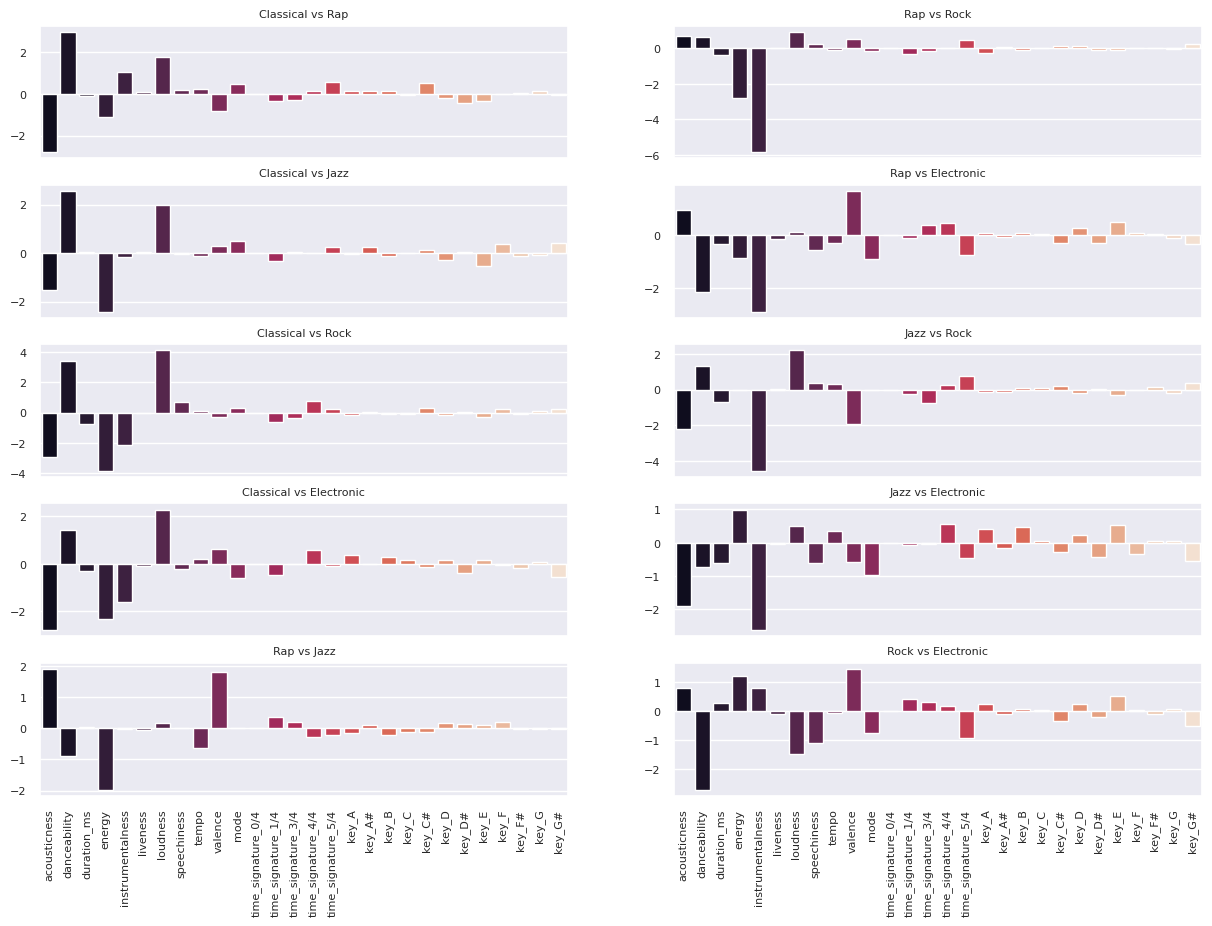

In [ ]:
fig, axes = plt.subplots(figsize=(15,10),nrows=5,ncols=2,sharex=True,sharey=False,squeeze=False)

print("\nCoeficientes LR + OVO\n")

counter = 0

for i in range(len(clf_ovo_log.classes_)):
  for j in range(i+1,len(clf_ovo_log.classes_)):
    estimator = clf_ovo_log.estimators_[counter]
    class1 = number_to_genre[clf_ovo_log.classes_[i]]
    class2 = number_to_genre[clf_ovo_log.classes_[j]]
    print("Par %d,%d - %s vs %s"%(i,j,class1,class2))
    w = estimator.coef_[0,:]
    b = estimator.intercept_

    max_feat = min(len(w),30)

    p=sns.barplot(x=np.arange(max_feat),y=w[:max_feat],palette="rocket",ax=axes[counter%5,counter//5],orient="v")
    axes[counter%5,counter//5].set_xticklabels(X.columns[:max_feat],fontsize=11)
    axes[counter%5,counter//5].set_title('%s vs %s'%(class1,class2),size=8)
    plt.setp(p.get_xticklabels(), rotation=90,size=8)

    counter+=1

print("\n")
plt.show()


* Averigue en qué consiste la técnica denominada "permutation importance" de sklearn y úsela para estimar la importancia de cada atributo en el clasificador multi-clase obtenido vía OVO.


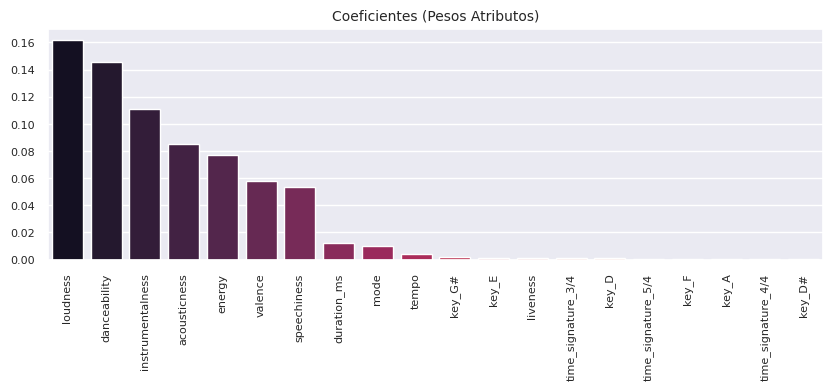

In [ ]:
from sklearn.inspection import permutation_importance
model_fi = permutation_importance(clf_ovo_log, X_train.values, y_train.values)

w = model_fi['importances_mean']
column_names = X_train.columns
max_feat = min(len(w),20)
sorted_idx = np.argsort(np.abs(w))[::-1]

fig, ax = plt.subplots(figsize=(10,3),nrows=1)
p = sns.barplot(x=np.arange(max_feat), y=[w[idx] for idx in sorted_idx[:max_feat]], palette="rocket",ax=ax)
ax.set_xticklabels([column_names[idx] for idx in sorted_idx[:max_feat]])
plt.setp(p.get_xticklabels(), rotation=90)
ax.set_title('Coeficientes (Pesos Atributos)',size=10)
plt.show()

* Como el regresor logístico es un clasificador probabilista, es posible obtener directamente (sin heurísticas) la incerteza de la predicción. Proponga un método que use esta información para rechazar la predicción de un % pequeño de datos de test. Determine si su método mejora las métricas del modelo logístico multi-class (obtenido sin heurísticas de agregación) cuando se evalúa sobre los datos que sí se predice.

In [ ]:
probs_train = clf_log.predict_proba(X_train.values)

ind_del = []
for i, p in enumerate(probs_train):
    if np.linalg.norm(p,np.inf)<0.4:
        ind_del.append(i)

X_train2 = np.delete(X_train.values, ind_del, 0)
y_train2 = np.delete(y_train.values, ind_del, 0)

print((X_train.shape[0]-X_train2.shape[0], X_train.shape[0], (X_train.shape[0]-X_train2.shape[0])/X_train.shape[0]))

print(clf_log.score(X_train,y_train))
print(classification_report(y_train, clf_log.predict(X_train), target_names=target_names))

print(clf_log.score(X_train2,y_train2))

print(classification_report(y_train2, clf_log.predict(X_train2), target_names=target_names))

(1936, 24508, 0.07899461400359066)
0.6819405908274849
              precision    recall  f1-score   support

   Classical       0.84      0.84      0.84      4926
         Rap       0.64      0.54      0.59      4904
        Jazz       0.62      0.54      0.58      4989
        Rock       0.70      0.78      0.73      4864
  Electronic       0.61      0.72      0.66      4825

    accuracy                           0.68     24508
   macro avg       0.68      0.68      0.68     24508
weighted avg       0.68      0.68      0.68     24508

0.7085326953748007
              precision    recall  f1-score   support

   Classical       0.85      0.85      0.85      4862
         Rap       0.67      0.57      0.61      4452
        Jazz       0.65      0.55      0.59      4592
        Rock       0.72      0.82      0.77      4409
  Electronic       0.64      0.76      0.69      4257

    accuracy                           0.71     22572
   macro avg       0.70      0.71      0.70     22572
weig

## P6. Validación Cruzada

*  Estime el error de prediccion de dos modelos a elección utilizando validación cruzada (CV). Para esto, una el conjunto de entrenamiento con el de validación y monitoree varias métricas de las elegidas anteriormente, incluyendo exactitud (accuracy). ¿Es conveniente el uso de validación cruzada en lugar de un conjunto de validación? Concluya. *Hint: Look up "cross_validate" function in scikit learn.*

In [ ]:
from sklearn.model_selection import cross_validate

# Note que X_Train es la unión de X_train (el conjunto de entrenamiento) con X_val (el conjunto de validación). Asimismo para y_Train
# Consideremos Perceptron OVO y Logistic OVO


scores_ovo_perceptron = cross_validate(
    clf_ovo_perceptron,
    X_Train, y_Train,
    return_train_score=True
    )
scores_ovo_log = cross_validate(
    clf_ovo_log,
    X_Train, y_Train,
    return_train_score=True
    )

display(scores_ovo_perceptron)
display(scores_ovo_log)

print('\nResultado Cross-Validation Perceptron OVO en Test Set: ')
print('Media:', scores_ovo_perceptron['test_score'].mean(), 'Desviación Estándar:', scores_ovo_perceptron['test_score'].std())
print('\nResultado Cross-Validation LogisticRegression OVO en Test Set: ')
print('Media:', scores_ovo_log['test_score'].mean(), 'Desviación Estándar:', scores_ovo_log['test_score'].std())

{'fit_time': array([0.15493155, 0.1723845 , 0.1716814 , 0.17353368, 0.17144895]),
 'score_time': array([0.02119136, 0.02274227, 0.02396846, 0.02020741, 0.02134037]),
 'test_score': array([0.58299331, 0.61090256, 0.61694141, 0.59213318, 0.6371797 ]),
 'train_score': array([0.58070834, 0.61767586, 0.62285784, 0.59874327, 0.62738698])}

{'fit_time': array([1.0337472 , 1.12795258, 1.10950136, 1.46173477, 2.02423573]),
 'score_time': array([0.02307367, 0.02110028, 0.02570653, 0.04237103, 0.05742311]),
 'test_score': array([0.69136608, 0.68712257, 0.68663294, 0.676677  , 0.69365105]),
 'train_score': array([0.68969316, 0.6901828 , 0.6888771 , 0.69246777, 0.68626571])}


Resultado Cross-Validation Perceptron OVO en Test Set: 
Media: 0.6080300310102824 Desviación Estándar: 0.01906260409535788

Resultado Cross-Validation LogisticRegression OVO en Test Set: 
Media: 0.6870899298188347 Desviación Estándar: 0.005830485016945589


* Evalúe los modelos sobre el conjunto de prueba. ¿El uso de validación cruzada permitió estimar mejor el comportamiento de los modelos en el conjunto de pruebas? Concluya.

R: Sí, usar crossvalidation nos permite evaluar el modelo de manera robusta, asegurándonos de que no hay overfitting.


In [ ]:
print('Resultado Cross-Validation Perceptron OVO en Training Set: ')
print('Media:', scores_ovo_perceptron['train_score'].mean(), 'Desviación Estándar:', scores_ovo_perceptron['train_score'].std())
print('\nResultado Cross-Validation LogisticRegression OVO en Training Set: ')
print('Media:', scores_ovo_log['train_score'].mean(), 'Desviación Estándar:', scores_ovo_log['train_score'].std())

Resultado Cross-Validation Perceptron OVO en Training Set: 
Media: 0.6094744573200588 Desviación Estándar: 0.017377481191383836

Resultado Cross-Validation LogisticRegression OVO en Training Set: 
Media: 0.6894973070017955 Desviación Estándar: 0.0020079721232877067


* Cargue su mejor modelo.

In [ ]:
# clasiffier_model = load('filename.joblib')

* Use validación cruzada para predecir si el uso de las características polinomiales "creadas" en la fase de ingeniería de atributos permite reducir el error de predicción. Solo como ejercicio académico, verifique esta predicción midiendo el error de pruebas del modelo con y sin las características polinomiales.

In [ ]:
clf_ovo_log_poly = OneVsOneClassifier(base).fit(X_Train_poly, y_Train_poly)

scores_ovo_log_poly = cross_validate(
    clf_ovo_log_poly,
    X_Train_poly, y_Train_poly,
    return_train_score=True
    )
display(scores_ovo_log_poly)

print('\nResultado Cross-Validation LogisticRegression OVO con características polinomiales en Test Set: ')
print('Media:', scores_ovo_log_poly['test_score'].mean(), 'Desviación Estándar:', scores_ovo_log_poly['test_score'].std())
print('\nResultado Cross-Validation LogisticRegression OVO con características polinomiales en Train Set: ')
print('Media:', scores_ovo_log_poly['train_score'].mean(), 'Desviación Estándar:', scores_ovo_log_poly['train_score'].std())

{'fit_time': array([ 9.50443649, 11.62607837,  5.9902966 ,  7.3500452 , 10.99142003]),
 'score_time': array([0.0810473 , 0.08019185, 0.0841856 , 0.06928611, 0.06633496]),
 'test_score': array([0.71960176, 0.71078831, 0.72368206, 0.71372613, 0.72564061]),
 'train_score': array([0.72661988, 0.73074098, 0.72596703, 0.72980251, 0.72600783])}


Resultado Cross-Validation LogisticRegression OVO con características polinomiales en Test Set: 
Media: 0.718687775420271 Desviación Estándar: 0.005676963334016863

Resultado Cross-Validation LogisticRegression OVO con características polinomiales en Train Set: 
Media: 0.7278276481149012 Desviación Estándar: 0.0020307601764195057


* Es posible que no lo haya notado, pero el modelo logístico implementado en sklearn contiene algunos "addons" que estudiaremos más adelante y que dependen de hiper-parámetros. Nos concentraremos primero en un hiper-parámetro de regularización denominado "C". Determine el mejor valor de este hiper-parámetro usando validación cruzada (elija una de las métricas monitoreadas hasta ahora). *Hint: this is when we use GridSearchCV.*


In [ ]:
from sklearn.model_selection import GridSearchCV
C = np.logspace(-3,3,10)
parameter={'C': C}
clf=GridSearchCV(base, parameter)
_ = clf.fit(X_Train, y_Train)

* Elija ahora el valor de "C" a partir del desempeño en el conjunto de entrenamiento. ¿Es esto correcto? ¿Obtiene resultados más apropiados usando CV?

In [ ]:
sorted(clf.cv_results_.keys())
print('Parámetros C encontrados, y su ranking: ')
display(clf.cv_results_['params'], clf.cv_results_['rank_test_score'])

print('\nAccuracy del clasificador con el mejor parámetro C encontrado: ')
idx = clf.cv_results_['rank_test_score'].tolist().index(1)
nuevo_clf=LogisticRegression(C=C[idx]).fit(X_Train,y_Train)
print('Conjunto de pruebas: ', nuevo_clf.score(X_Train,y_Train))
print('Conjunto de test:    ', nuevo_clf.score(X_test, y_test))

Parámetros C encontrados, y su ranking: 


[{'C': 0.001},
 {'C': 0.004641588833612777},
 {'C': 0.021544346900318832},
 {'C': 0.1},
 {'C': 0.46415888336127775},
 {'C': 2.154434690031882},
 {'C': 10.0},
 {'C': 46.41588833612773},
 {'C': 215.44346900318823},
 {'C': 1000.0}]

array([10,  9,  8,  7,  6,  5,  3,  1,  3,  2], dtype=int32)


Accuracy del clasificador con el mejor parámetro C encontrado: 
Conjunto de pruebas:  0.6809531581524401
Conjunto de test:     0.6855533465871438


##  Comentarios Finales
Nos parecio una muy buena introducción, ya que nos facilitó a la visualización de datos, el preprocesamiento de datos, el entrenamiento de clasificadores y calificación de clasificadores.

Posteriormente, el proceso de investigación y desarrollo de los clasificadores nos sirvieron enormemente para entender conceptos de Machine Learning y el funcionamiento de los modelos.

En nuestro caso, estamos comenzando a utilizar herramientas de Data Science y es primera vez que utilizamos métodos de clasificación basados en Aprendizaje de Máquina, por tanto, fue una experiencia muy enriquecedora.

## Referencias

***Recuerde si utiliza código disponible en internet siempre debe referenciarlo***. 🤓



*   Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.
*   The pandas development team. (2023). pandas-dev/pandas: Pandas (v1.5.3). Zenodo
*   Harris, C.R., Millman, K.J., van der Walt, S.J. et al. Array programming with NumPy. Nature 585, 357–362 (2020). DOI: 10.1038/s41586-020-2649-2.
*   J. D. Hunter, "Matplotlib: A 2D Graphics Environment", Computing in Science & Engineering, vol. 9, no. 3, pp. 90-95, 2007.
*   Michael L. Waskom, seaborn: statistical data visualization, Jounral of Open Source Software (2021). DOI: 10.21105/joss.03021